In [1]:
### Function One

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

In [3]:
X = np.load("function_1/initial_inputs.npy")

In [4]:
y = np.load("function_1/initial_outputs.npy")

In [5]:
y

array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048])

In [6]:
new_rows = [np.array(row) for row in [
    [0.959595, 0.858585],
    [0.839195, 0.748743],
    [0.733668, 0.748743],
    [0.080808, 0.404040],
    [0.727272, 0.737373],
    [0.727272, 0.727272],
    [0.727272, 0.727272],
    [0.727271, 0.727271],
    [0.707070, 0.737373],
    [0.707070, 0.717171],
    [0.686868, 0.727272],
    [0.686868, 0.696969]
]]


In [7]:
for row in new_rows:
    X = np.append(X, [row], axis=0)

In [8]:
X

array([[0.31940389, 0.76295937],
       [0.57432921, 0.8798981 ],
       [0.73102363, 0.73299988],
       [0.84035342, 0.26473161],
       [0.65011406, 0.68152635],
       [0.41043714, 0.1475543 ],
       [0.31269116, 0.07872278],
       [0.68341817, 0.86105746],
       [0.08250725, 0.40348751],
       [0.88388983, 0.58225397],
       [0.959595  , 0.858585  ],
       [0.839195  , 0.748743  ],
       [0.733668  , 0.748743  ],
       [0.080808  , 0.40404   ],
       [0.727272  , 0.737373  ],
       [0.727272  , 0.727272  ],
       [0.727272  , 0.727272  ],
       [0.727271  , 0.727271  ],
       [0.70707   , 0.737373  ],
       [0.70707   , 0.717171  ],
       [0.686868  , 0.727272  ],
       [0.686868  , 0.696969  ]])

In [11]:
new_output_rows = [
    [-1.790789192954543e-113],
    [-1.3793248852179627e-42],
    [-1.7707922454789942e-19],
    [5.34214011784672e-82],
    [4.811276598698796e-16],
    [2.7097266627552453e-14],
    [2.7097266627552453e-14],
    [2.711666244175267e-14],
    [2.14313318892057e-13],
    [3.3176397690319093e-10],
    [6.952409814628062e-10],
    [0.000003061168400631731],
    [0.000003061168400631731]
    
]

In [12]:
y

array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048])

In [13]:
for row in new_output_rows:
    y = np.append(y, row, axis=0)

In [14]:
y

array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048, -1.79078919e-113, -1.37932489e-042,
       -1.77079225e-019,  5.34214012e-082,  4.81127660e-016,
        2.70972666e-014,  2.70972666e-014,  2.71166624e-014,
        2.14313319e-013,  3.31763977e-010,  6.95240981e-010,
        3.06116840e-006])

In [15]:
max(y)

3.061168400631731e-06

In [16]:
y

array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048, -1.79078919e-113, -1.37932489e-042,
       -1.77079225e-019,  5.34214012e-082,  4.81127660e-016,
        2.70972666e-014,  2.70972666e-014,  2.71166624e-014,
        2.14313319e-013,  3.31763977e-010,  6.95240981e-010,
        3.06116840e-006])

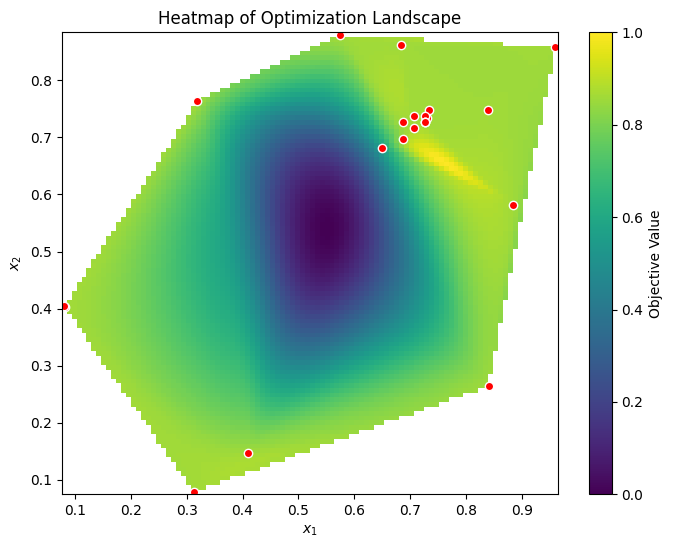

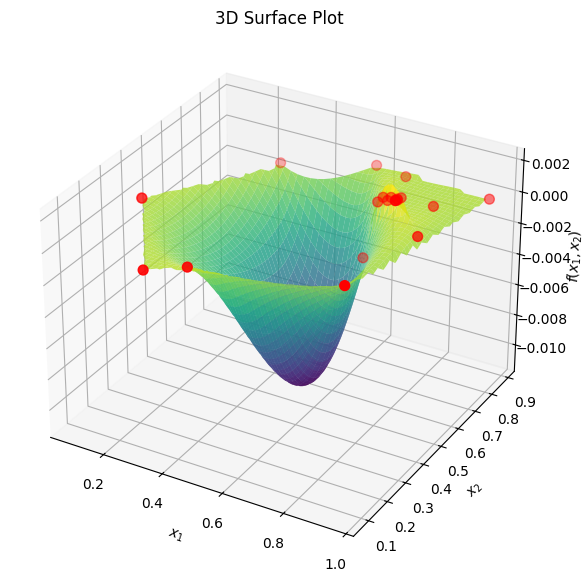

In [17]:
### VIZ CODE
from scipy.interpolate import griddata

x_axis = X[:, 0]
y_axis = X[:, 1]

# 2. Create a dense grid for interpolation
xi = np.linspace(x_axis.min(), x_axis.max(), 100)
yi = np.linspace(y_axis.min(), y_axis.max(), 100)
XI, YI = np.meshgrid(xi, yi)

# 3. Interpolate the points onto the grid
ZI = griddata((x_axis, y_axis), y, (XI, YI), method='cubic')

# --- Plotting Heatmap ---
plt.figure(figsize=(8, 6))
plt.pcolormesh(XI, YI, ZI, shading='auto', cmap='viridis')
plt.scatter(x_axis, y_axis, c='red', edgecolors='white', label='Sample Points')
plt.colorbar(label='Objective Value')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Heatmap of Optimization Landscape')
plt.show()

# --- Plotting 3D Surface ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(XI, YI, ZI, cmap='viridis', alpha=0.8)
ax.scatter(x_axis, y_axis, y, color='red', s=50)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1, x_2)$')
plt.title('3D Surface Plot')
plt.show()

In [18]:
# Apply the transform to your outputs
# Using a scaling factor (C) to bring tiny values into a readable range
offset = 1e80
y = np.sign(y) * np.log1p(offset * np.abs(y))

In [19]:
y

array([ 2.65512543e+00,  7.83204361e+01,  1.49408078e+02,  3.34177101e-44,
       -1.78581669e+02, -6.06369729e+01, -2.08909327e-11,  9.30335978e+01,
        3.07982457e-01,  7.55120763e+01, -1.79078919e-33, -8.78198277e+01,
       -1.41029118e+02,  5.20433441e-02,  1.48936408e+02,  1.52967464e+02,
        1.52967464e+02,  1.52968179e+02,  1.55035470e+02,  1.62380210e+02,
        1.63120045e+02,  1.71510094e+02])

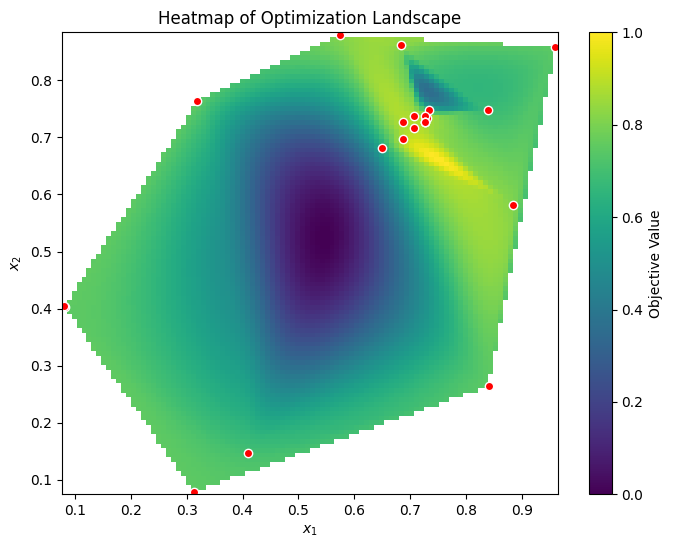

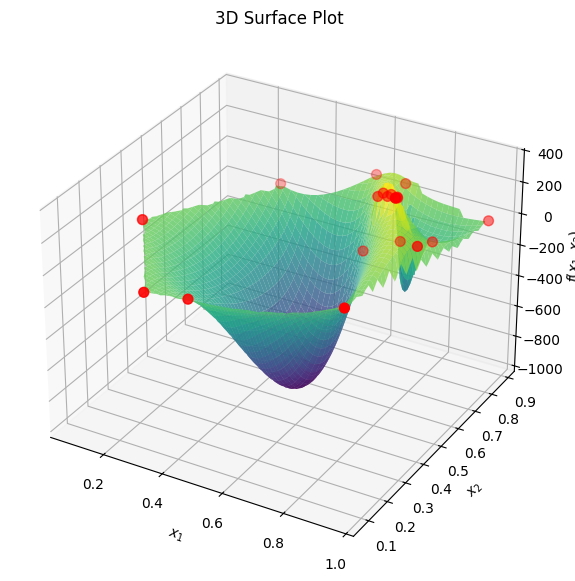

In [20]:
# VIZ after log-scale

### VIZ CODE
from scipy.interpolate import griddata

x_axis = X[:, 0]
y_axis = X[:, 1]

# 2. Create a dense grid for interpolation
xi = np.linspace(x_axis.min(), x_axis.max(), 100)
yi = np.linspace(y_axis.min(), y_axis.max(), 100)
XI, YI = np.meshgrid(xi, yi)

# 3. Interpolate the points onto the grid
ZI = griddata((x_axis, y_axis), y, (XI, YI), method='cubic')

# --- Plotting Heatmap ---
plt.figure(figsize=(8, 6))
plt.pcolormesh(XI, YI, ZI, shading='auto', cmap='viridis')
plt.scatter(x_axis, y_axis, c='red', edgecolors='white', label='Sample Points')
plt.colorbar(label='Objective Value')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Heatmap of Optimization Landscape')
plt.show()

# --- Plotting 3D Surface ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(XI, YI, ZI, cmap='viridis', alpha=0.8)
ax.scatter(x_axis, y_axis, y, color='red', s=50)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1, x_2)$')
plt.title('3D Surface Plot')
plt.show()

In [19]:



from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.05, length_scale_bounds=(1e-3, 0.2))

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-1,           # Increased slightly for numerical stability
    n_restarts_optimizer=40 # More restarts help avoid local minima in sharp peaks
)

model.fit(X, y) # Ensure 'y' is your transformed output


/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(length_scale=0.05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.1
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",40
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glo

In [20]:
# 3. Create a search grid to find the next point
x_coords = np.linspace(0, 1, 100)
y_coords = np.linspace(0, 1, 100)
x_grid, y_grid = np.meshgrid(x_coords, y_coords)
X_test = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

In [21]:
# 4. Predict Mean and Uncertainty (Standard Deviation)
mean, std = model.predict(X_test, return_std=True)

In [26]:
kappa = 100
ucb = mean + kappa * std
next_idx = np.argmax(ucb)
next_point = X_test[next_idx]

print(f"Suggested Next Iteration Point: {next_point}")

Suggested Next Iteration Point: [0.68686869 0.6969697 ]


In [27]:
# EI 

In [28]:
from scipy.stats import norm


def expected_improvement(X, model, current_best, xi=0):
    """
    X: Points at which to evaluate EI
    model: Trained Gaussian Process
    current_best: Highest value found so far
    xi: Exploration parameter (higher = more exploration)
    """
    mu, sigma = model.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    # Avoid division by zero
    mask = sigma > 0
    ei = np.zeros_like(mu)

    # Calculate Z with the exploration parameter xi
    # Standard EI: (mu - current_best) / sigma
    # Exploration EI: (mu - current_best - xi) / sigma
    improvement = mu[mask] - current_best - xi
    z = improvement / sigma[mask]
    
    ei[mask] = (improvement * norm.cdf(z) + 
                sigma[mask] * norm.pdf(z))
    
    return ei

In [29]:
# Get your current best output
current_best_y = np.max(y) 



In [30]:
# Calculate EI for all points in your grid
ei_values = expected_improvement(X_test, model, current_best_y,xi=100)
next_idx = np.argmax(ei_values)
next_point = X_test[next_idx]
print(next_point)

[0.6969697  0.72727273]


In [31]:
# Fourth iteration - continue explore more of the universe inspired by heatmap and 3D plot

In [32]:
# SVM for likely candidate
print(X)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.959595   0.858585  ]
 [0.839195   0.748743  ]
 [0.733668   0.748743  ]
 [0.080808   0.40404   ]
 [0.727272   0.737373  ]
 [0.727272   0.727272  ]
 [0.727272   0.727272  ]
 [0.727271   0.727271  ]
 [0.70707    0.737373  ]
 [0.70707    0.717171  ]
 [0.686868   0.727272  ]]


In [33]:
print(y)

[ 2.65512543e+00  7.83204361e+01  1.49408078e+02  3.34177101e-44
 -1.78581669e+02 -6.06369729e+01 -2.08909327e-11  9.30335978e+01
  3.07982457e-01  7.55120763e+01 -1.79078919e-33 -8.78198277e+01
 -1.41029118e+02  5.20433441e-02  1.48936408e+02  1.52967464e+02
  1.52967464e+02  1.52968179e+02  1.55035470e+02  1.62380210e+02
  1.63120045e+02]


In [34]:
type(X)

numpy.ndarray

In [35]:
type(y)

numpy.ndarray

In [36]:
from sklearn import svm

# Define the kernels you want to test
# kernels = ['linear', 'rbf', 'poly']
kernels = ['linear', 'rbf', 'poly']


# Custom Labels: Start with all zeros (Negative)
y_labels = np.zeros(len(X))

# Set indices 4, 9, 10, 11, 12 to 1 (Positive)
positive_indices = [4, 9, 10, 11, 12]
y_labels[positive_indices] = 1

for k in kernels:
    # Build the model
    # gamma='auto' or 'scale' is important for RBF/Poly
    clf = svm.SVC(kernel=k, C=20.0, gamma='scale', degree=3) 
    clf.fit(X, y_labels)
    
    print(f"Kernel: {k}")
    print(f"Number of Support Vectors: {sum(clf.n_support_)}")
    
    # 4. Identify Support Vectors
    support_vector_indices = clf.support_
    support_vectors = clf.support_vectors_
    n_per_class = clf.n_support_
    
    print(f"Indices of support vectors: {support_vector_indices}")
    print(f"Support Vector Coordinates:\n {support_vectors}")
    print(f"Number of support vectors for each class: {n_per_class}")
    print("\n")
    predictions = clf.predict([next_point])

    # 4. See the raw 'distance' from the boundary (Decision Function)
    # This is the SVM equivalent of a "probability"
    scores = clf.decision_function([next_point])

    for i, (pred, score) in enumerate(zip(predictions, scores)):
        print(f"Sample {i} | Predicted Class: {pred} | Distance from Margin: {score:.4f}")
        
    print("\n")

    

Kernel: linear
Number of Support Vectors: 11
Indices of support vectors: [ 2  3 14 15 16 17  4  9 10 11 12]
Support Vector Coordinates:
 [[0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.727272   0.737373  ]
 [0.727272   0.727272  ]
 [0.727272   0.727272  ]
 [0.727271   0.727271  ]
 [0.65011406 0.68152635]
 [0.88388983 0.58225397]
 [0.959595   0.858585  ]
 [0.839195   0.748743  ]
 [0.733668   0.748743  ]]
Number of support vectors for each class: [6 5]


Sample 0 | Predicted Class: 0.0 | Distance from Margin: -1.2288


Kernel: rbf
Number of Support Vectors: 11
Indices of support vectors: [ 0  2  3  5  6  8 15 16  4 11 12]
Support Vector Coordinates:
 [[0.31940389 0.76295937]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.08250725 0.40348751]
 [0.727272   0.727272  ]
 [0.727272   0.727272  ]
 [0.65011406 0.68152635]
 [0.839195   0.748743  ]
 [0.733668   0.748743  ]]
Number of support vectors for each class: [8 3]


Sample 0 | 

In [37]:
# Linear regression

In [38]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


# Initialize and Fit
lin_reg = LinearRegression()
lin_reg.fit(X, y)

prediction = lin_reg.predict([next_point])
print(f"Linear Regression Prediction: ${prediction[0]:,.2f}")
print(f"Coefficients: {lin_reg.coef_}, Intercept: {lin_reg.intercept_}")

Linear Regression Prediction: $62.82
Coefficients: [ 30.65397282 125.39466408], Intercept: -49.74254925010691


In [39]:
# Logistic regression

In [40]:
from sklearn.linear_model import LogisticRegression


# Initialize and Fit
log_reg = LogisticRegression()
log_reg.fit(X, y_labels)

# Predict the probability of index 4 being '1'
prob = log_reg.predict_proba([next_point])
print(f"Probability of Class 0 vs Class 1: {prob}")

# Predict the actual class
label = log_reg.predict([next_point])
print(f"Predicted Class: {label}")

Probability of Class 0 vs Class 1: [[0.74838292 0.25161708]]
Predicted Class: [0.]


In [41]:
# Simple NN

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Setup Data
X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)

# Labels: Indices 4, 9, 10, 11, 12 as 1, rest as 0
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

# 2. Build a simple 1-layer Neural Network (Logistic Regression style)
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

# 3. Train the model briefly
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.BCELoss()

for _ in range(1000):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

# 4. IDENTIFY GRADIENT CONTRIBUTION (The "Support Vector" equivalent)
# We want the gradient of the output with respect to the input X
model.zero_grad()
output = model(X_tensor)
output.backward(torch.ones_like(output))

# Get the absolute magnitude of gradients for each input point
importances = X_tensor.grad.abs().sum(dim=1)

for i, imp in enumerate(importances):
    print(f"Point {i} contribution score: {imp.item():.4f}")

Point 0 contribution score: 7.9108
Point 1 contribution score: 9.9288
Point 2 contribution score: 11.4032
Point 3 contribution score: 12.5746
Point 4 contribution score: 29.4797
Point 5 contribution score: 8.7273
Point 6 contribution score: 8.0214
Point 7 contribution score: 10.9267
Point 8 contribution score: 6.4604
Point 9 contribution score: 27.1583
Point 10 contribution score: 26.3998
Point 11 contribution score: 27.6477
Point 12 contribution score: 28.7005
Point 13 contribution score: 6.4505
Point 14 contribution score: 11.3662
Point 15 contribution score: 11.3679
Point 16 contribution score: 11.3679
Point 17 contribution score: 11.3679
Point 18 contribution score: 11.1720
Point 19 contribution score: 11.1755
Point 20 contribution score: 10.9819


In [43]:

# Access the raw gradients
# Shape will be (13, 2) - one gradient for each coordinate (x1, x2)
raw_gradients = X_tensor.grad.data.numpy()

# Calculate "Importance" (Magnitude of the gradient)
# We sum the absolute values of the gradients for each point
importance_scores = torch.abs(X_tensor.grad).sum(dim=1).detach().numpy()

print("Point Index | Gradient (x1) | Gradient (x2) | Total Importance")
for i, score in enumerate(importance_scores):
    print(f"Index {i:2d}    | {raw_gradients[i][0]:.4f}      | {raw_gradients[i][1]:.4f}      | {score:.4f}")

Point Index | Gradient (x1) | Gradient (x2) | Total Importance
Index  0    | 6.0409      | -1.8699      | 7.9108
Index  1    | 8.1935      | -1.7353      | 9.9288
Index  2    | 9.6458      | -1.7575      | 11.4032
Index  3    | 10.6140      | -1.9607      | 12.5746
Index  4    | -24.5289      | 4.9508      | 29.4797
Index  5    | 6.5624      | -2.1648      | 8.7273
Index  6    | 5.7893      | -2.2321      | 8.0214
Index  7    | 9.2166      | -1.7100      | 10.9267
Index  8    | 4.3381      | -2.1224      | 6.4604
Index  9    | -22.1803      | 4.9781      | 27.1583
Index 10    | -21.2613      | 5.1386      | 26.3998
Index 11    | -22.6018      | 5.0459      | 27.6477
Index 12    | -23.6892      | 5.0113      | 28.7005
Index 13    | 4.3279      | -2.1225      | 6.4505
Index 14    | 9.6097      | -1.7565      | 11.3662
Index 15    | 9.6064      | -1.7615      | 11.3679
Index 16    | 9.6064      | -1.7615      | 11.3679
Index 17    | 9.6064      | -1.7615      | 11.3679
Index 18    | 9.409

In [44]:
import torch

# 1. Prepare your sample input (must be a 2D tensor)
sample_input = torch.tensor([next_point], dtype=torch.float32)

# 2. Put the model in evaluation mode
model.eval()

# 3. Use 'no_grad' to save memory and compute power
with torch.no_grad():
    prediction_prob = model(sample_input)

# 4. View results
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")

# Convert probability to a hard label
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Probability of being Positive (Class 1): 0.2715
Predicted Class: 0


/var/folders/b1/jr7k43v1395g6gvnq7gz_qq80000gn/T/ipykernel_4341/1102642691.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  sample_input = torch.tensor([next_point], dtype=torch.float32)


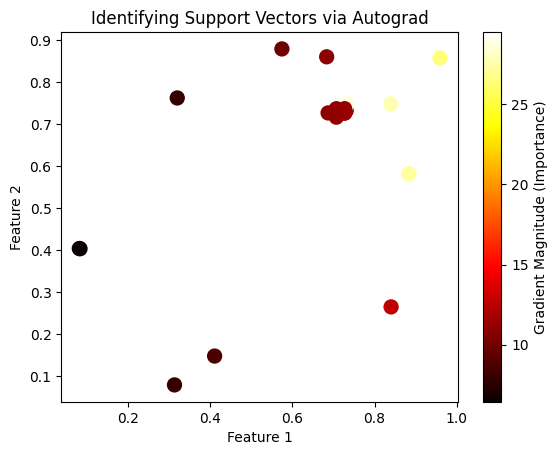

In [45]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=importance_scores, cmap='hot', s=100)
plt.colorbar(label='Gradient Magnitude (Importance)')
plt.title('Identifying Support Vectors via Autograd')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [46]:
# Deep layer

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define a deeper architecture
model = nn.Sequential(
    nn.Linear(2, 10),      # Hidden layer: 2 inputs -> 10 neurons
    nn.ReLU(),             # Non-linear activation
    nn.Linear(10, 1),      # Output layer: 10 neurons -> 1 output
    nn.Sigmoid()
)

# 2. Setup the rest as before
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam is better for deeper nets
criterion = nn.BCELoss()

# 3. Training Loop
for _ in range(2000):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

In [48]:
# Clear gradients and do a fresh pass for saliency
X_tensor.grad.zero_()
output = model(X_tensor)
output.backward(torch.ones_like(output))

# Importance scores
deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.0001
 1    | 0.0034
 2    | 11.8149
 3    | 0.3101
 4    | 7.5344
 5    | 0.0388
 6    | 0.0090
 7    | 0.1330
 8    | 0.0018
 9    | 0.1948
10    | 6.6856
11    | 7.6224
12    | 9.6907
13    | 0.0017
14    | 10.5493
15    | 12.1291
16    | 12.1291
17    | 12.1291
18    | 7.3887
19    | 10.6682
20    | 6.0268


In [49]:
import torch

# 1. Prepare your sample input (must be a 2D tensor)
sample_input = torch.tensor([next_point], dtype=torch.float32)

# 2. Put the model in evaluation mode
model.eval()

# 3. Use 'no_grad' to save memory and compute power
with torch.no_grad():
    prediction_prob = model(sample_input)

# 4. View results
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")

# Convert probability to a hard label
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Probability of being Positive (Class 1): 0.1508
Predicted Class: 0


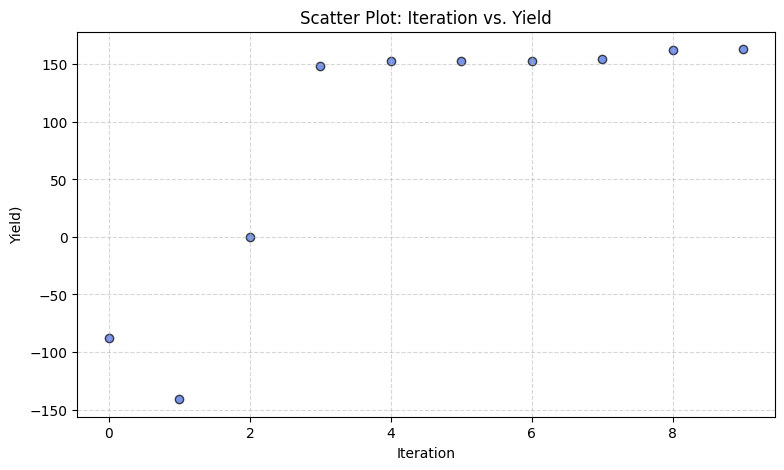

In [50]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0,10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)

# 3. Customization
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()